# Time for things to start get interesting...so what is a filter?

One of the most important concepts in all of navigation is **filters**. In simple terms, a filter is basically an algorithm that takes super messy data (which is what most sensor data is) and tries to produce a cleaner or more useful version of it (which is what you really want).

The sensors in any tech, whether its an Iphone, the laptop you're reading this on, or more importantly, MIDAS, are not perfect. An altimeter, IMU, GPS, pressure sensor, etc. will all have some varying level of noise. If we trusted every measurement exactly as it came in, our estimate of the rocket's state would jump around like crazy. Look at this...this is from an arduino (with an MPU6050 which is an accelerometer) just laying flat on the table: 

![Alternative text](mpu6050_noise.png)

A filter gives us a true estimate based on **what we measured with what we already believe is happening.**

In simple words:

- Measurements are noisy
- Filters smooth or estimate signals
- The goal is not always to remove all motion
- The goal is usually to remove the random garbage while keeping the real trend

We will talk about the anticipated Kalman Filter next module. This is just the stepping stone. Trust me...the Kalman Filter will become trivial after this. 

### First lets make some fake flight data.

Suppose our rocket is ascending up, and our sensor measures altitude. From physics you know the true altitude is smooth (lets ignore drag for *now*), but the measurement has noise added to it.

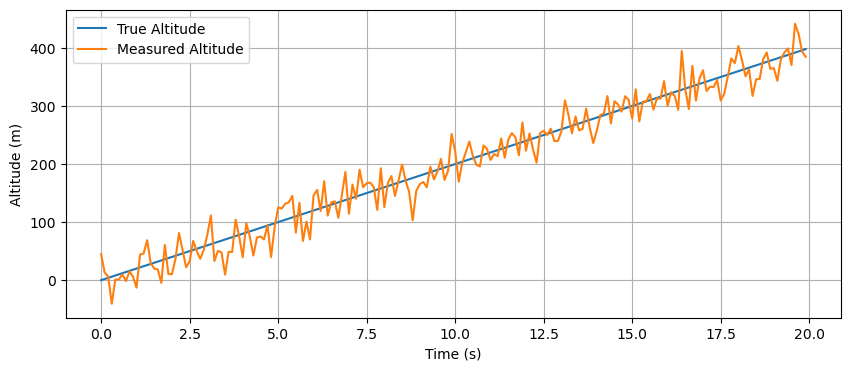

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

time = np.arange(0, 20, 0.1)
true_altitude = 20 * time
noise = np.random.normal(0, 25, len(time))
measured_altitude = true_altitude + noise

plt.figure(figsize=(10, 4))
plt.plot(time, true_altitude, label="True Altitude")
plt.plot(time, measured_altitude, label="Measured Altitude")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

You don't generally know your true altitude and only rely on the measurements coming in from your sensors. Notice how the measured altitude is generally increasing, but its super noisy. The filter's job is to make that measurement actually usable and produce an estimated altitude that can match the true one.

**Moving Average Filter**

The moving average filter is probably the easiest filter to understand.

Instead of trusting one measurement, we average the last few measurements.

For example, if our last 3 measurements are:

$z = [100, 110, 90]$

then the moving average is:

$\frac{100 + 110 + 90}{3} = 100$

This helps smooth out random spikes.

Now in python....

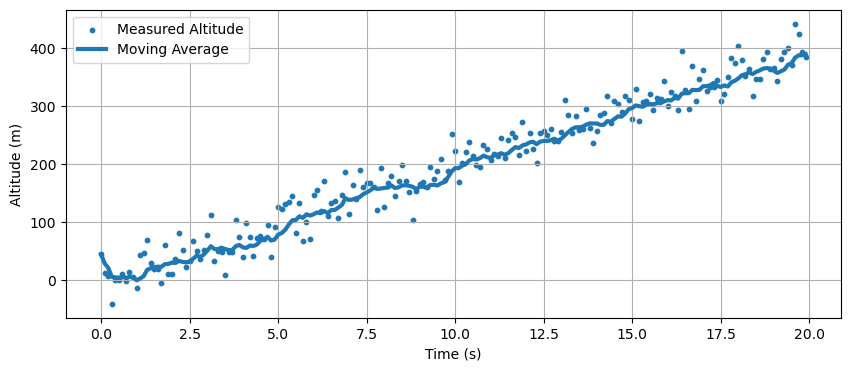

In [5]:
def moving_average(data, window_size):
    filtered_data = []

    for i in range(len(data)):
        start_index = max(0, i - window_size + 1)
        window = data[start_index:i+1]
        filtered_data.append(np.mean(window))

    return np.array(filtered_data)

moving_average_altitude = moving_average(measured_altitude, 10)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, moving_average_altitude, label="Moving Average", linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

The moving average looks smoother, but there is a tradeoff.

If we average too many points, the filter becomes smoother but also slower to react.

This delay is called **lag**. You will see this tradeoff alot in GNC.

### 🎯 Your Turn

Change the `window_size` below.

Try:

- 3
- 10
- 30

What happens when the window gets larger?

In [ ]:
window_size = 10

filtered = moving_average(measured_altitude, window_size)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, filtered, label="Moving Average")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

**Low-Pass Filter**

A low-pass filter lets slow changes pass through, while reducing fast changes.

That sounds fancy, but all it means is:

- Real rocket altitude changes smoothly
- Random sensor noise jumps around quickly
- A low-pass filter keeps the smooth part and reduces the jumpy part

A simple low-pass filter looks like:

$filtered_k = \alpha measurement_k + (1 - \alpha) filtered_{k-1}$

Where $\alpha$ controls how much we trust the newest measurement.

If $\alpha$ is large, we trust the measurement more.

If $\alpha$ is small, we trust our previous filtered value more.

Now in python....

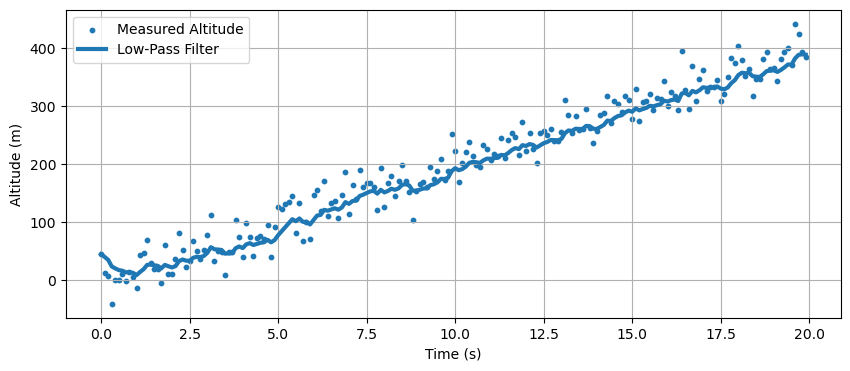

In [6]:
def low_pass_filter(data, alpha):
    filtered_data = []
    filtered_value = data[0]

    for measurement in data:
        filtered_value = alpha * measurement + (1 - alpha) * filtered_value
        filtered_data.append(filtered_value)

    return np.array(filtered_data)

low_pass_altitude = low_pass_filter(measured_altitude, alpha=0.15)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, low_pass_altitude, label="Low-Pass Filter", linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

### 🎯 Your Turn

Change `alpha` below.

Try values like:

- 0.05
- 0.2
- 0.8

Which one is smoother? Which one reacts faster?

In [ ]:
alpha = 0.2

filtered = low_pass_filter(measured_altitude, alpha)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, filtered, label="Low-Pass Filter")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

**Alpha Filter**

An alpha filter is basically the same idea as the low-pass filter, but written in a way that starts to look more like GNC estimation.

We have:

- A measurement $z$
- An estimate $\hat{x}$
- A correction based on the error

The equation is:

$\hat{x}_{new} = \hat{x}_{old} + \alpha(z - \hat{x}_{old})$

The term $(z - \hat{x}_{old})$ is called the residual or error.

It asks: how far away was my estimate from the measurement?

Now in python....

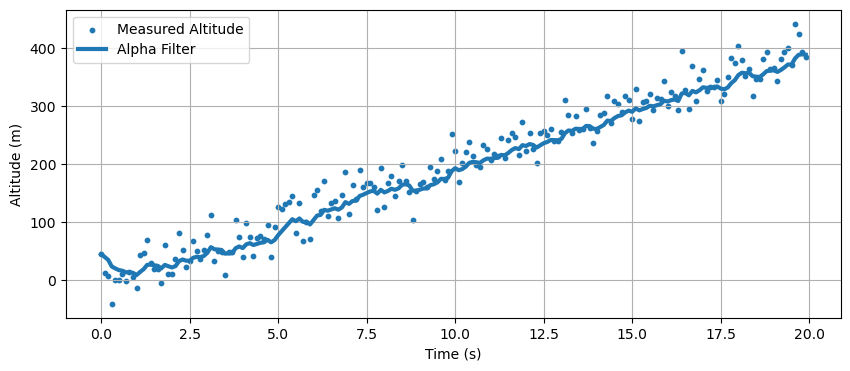

In [7]:
def alpha_filter(measurements, alpha):
    estimates = []
    estimate = measurements[0]

    for z in measurements:
        residual = z - estimate
        estimate = estimate + alpha * residual
        estimates.append(estimate)

    return np.array(estimates)

alpha_altitude = alpha_filter(measured_altitude, alpha=0.15)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, alpha_altitude, label="Alpha Filter", linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

Notice how similar this looked to the low-pass filter.

The difference is mostly the way we think about it. The alpha filter is phrased like an estimate being corrected by a measurement.

### 🎯 Your Turn

Use the alpha filter on the measured altitude with your own alpha value.

Then plot the measured altitude and filtered altitude together.

In [ ]:
# Write your code here

**Alpha Beta Gamma Filter**

Okay now lets make it a little more useful.

The alpha filter only estimates position. But for a rocket, we usually care about:

- Position
- Velocity
- Acceleration

The alpha beta gamma filter estimates all three.

The idea is:

1. Predict where the rocket should be using position, velocity, and acceleration
2. Compare that prediction to the measurement
3. Correct position, velocity, and acceleration using the error

This starts to look alot like the structure of a kalman filter, just without the matrix probability stuff yet.

For constant acceleration motion, the prediction equations are:

$x_{pred} = x + v\Delta t + \frac{1}{2}a\Delta t^2$

$v_{pred} = v + a\Delta t$

$a_{pred} = a$

Then we compute the residual:

$residual = z - x_{pred}$

Then we correct:

$x = x_{pred} + \alpha residual$

$v = v_{pred} + \frac{\beta}{\Delta t} residual$

$a = a_{pred} + \frac{\gamma}{0.5\Delta t^2} residual$

Now in python....

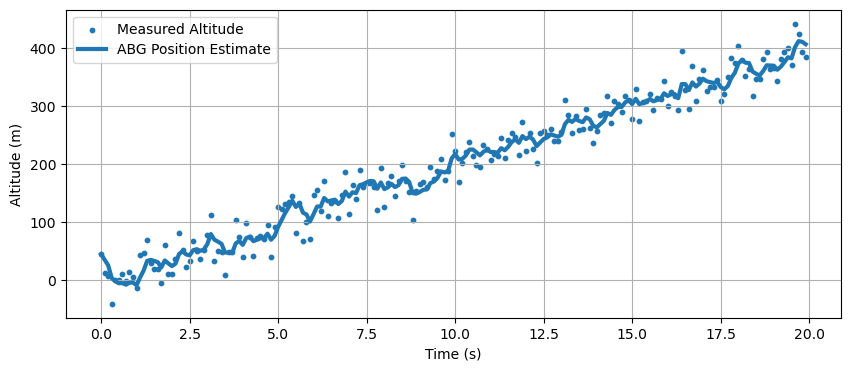

In [8]:
def alpha_beta_gamma_filter(measurements, dt, alpha, beta, gamma):
    positions = []
    velocities = []
    accelerations = []

    position = measurements[0]
    velocity = 0
    acceleration = 0

    for z in measurements:
        predicted_position = position + velocity * dt + 0.5 * acceleration * dt**2
        predicted_velocity = velocity + acceleration * dt
        predicted_acceleration = acceleration

        residual = z - predicted_position

        position = predicted_position + alpha * residual
        velocity = predicted_velocity + (beta / dt) * residual
        acceleration = predicted_acceleration + (gamma / (0.5 * dt**2)) * residual

        positions.append(position)
        velocities.append(velocity)
        accelerations.append(acceleration)

    return np.array(positions), np.array(velocities), np.array(accelerations)

dt = 0.1
position_estimate, velocity_estimate, acceleration_estimate = alpha_beta_gamma_filter(
    measured_altitude,
    dt,
    alpha=0.3,
    beta=0.05,
    gamma=0.001
)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, position_estimate, label="ABG Position Estimate", linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

Now we have an estimated position, velocity, and acceleration.

Remember, the sensor only measured position. The filter gave us velocity and acceleration estimates from how the position changed over time.

This is very useful in navigation.

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(time, velocity_estimate, label="Estimated Velocity")
plt.plot(time, acceleration_estimate, label="Estimated Acceleration")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)
plt.show()

### 🎯 Your Turn

Change `alpha`, `beta`, and `gamma` in the alpha beta gamma filter.

Try to answer:

- What happens if alpha is larger?
- What happens if beta is larger?
- What happens if gamma is too large?

You do not need perfect values. Just get a feel for how the filter reacts.

In [ ]:
# Write your code here

### 🚀 Challenge:  Filtering Rocket Altitude

A rocket altitude sensor gives the noisy measurements below.

Your Tasks:

- Create a moving average filter with a window size of 5
- Create a low-pass filter with alpha = 0.2
- Create an alpha filter with alpha = 0.2
- Plot all three filtered signals with the original measurements
- Which one looks smoothest?
- Which one seems to react fastest?

This is the main tradeoff filters usually make: smoothness vs. reaction speed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

time = np.arange(0, 15, 0.1)
true_altitude = 15 * time + 0.5 * time**2
measured_altitude = true_altitude + np.random.normal(0, 20, len(time))

# Write your code here

**Summary**

Filters are algorithms that help clean up or estimate useful information from noisy measurements.

In this module we covered:

- Moving average filters
- Low-pass filters
- Alpha filters
- Alpha beta gamma filters

The big idea is that filters balance trusting the measurement vs trusting the previous estimate.

If you understand that sentence, you understand the main intuition behind alot of GNC filtering. Kalman filters will build directly off this idea, but with a more formal way of deciding how much to trust each side.